# Day 6 · K-Means + PCA —— 没有标签怎么学？

> 目标：手写 K-Means 聚类 + 手写 PCA 降维，理解无监督学习的核心思想
>
> Day 1-5 都是监督学习（有 y），今天开始** unsupervised learning**（没有 y）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
print('=' * 40)
print('Day 6 · K-Means + PCA')
print('=' * 40)

Day 6 · K-Means + PCA


## 1. K-Means 核心思想

> 没有标签 → 那就让数据自己"聚"成 K 个团

**三步循环，直到收敛：**
1. **分派**：每个点找最近的质心，归入该簇
2. **更新**：重新算每个簇的均值 → 新质心
3. **重复**：质心不再动了就停

**直觉类比（C++ 角度）：**
```
// 就像一群点，随机扔 K 个磁铁（质心）
// 每轮：点被最近的磁铁吸走 → 磁铁移到簇的中心
// 反复 → 磁铁不再移动 → 收敛

while (质心还在动) {
    for (每个点)    点.簇 = 最近的质心;       // O(n*K*d)
    for (每个簇)    质心 = 簇内点的均值;       // O(n*d)
}
```

**K-Means 的两大软肋（提前知道）：**
- 要提前指定 K → Elbow method 补救
- 对初始质心敏感 → KMeans++ 补救

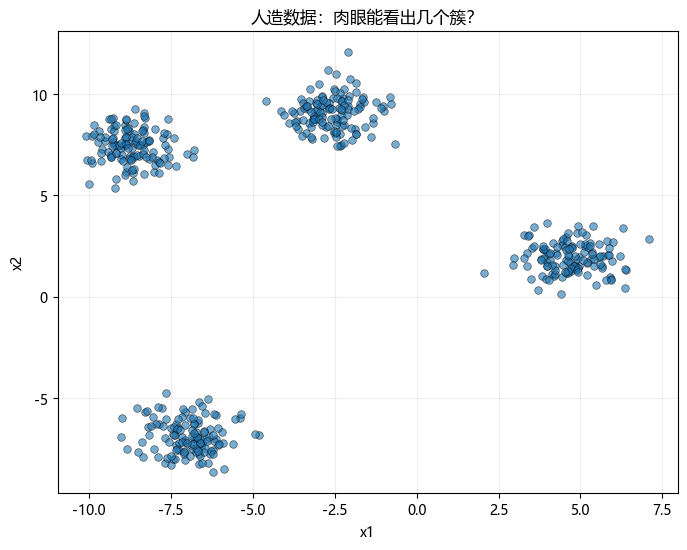

数据形状: (500, 2)
真实标签: [0 1 2 3]  (但我们假装不知道)


In [2]:
# 造一个"一眼就能看出几类"的数据
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.title('人造数据：肉眼能看出几个簇？')
plt.xlabel('x1'); plt.ylabel('x2')
plt.grid(True, alpha=0.2)
plt.show()

print(f'数据形状: {X.shape}')
print(f'真实标签: {np.unique(y_true)}  (但我们假装不知道)')

---

## 2. 手写 K-Means —— 从零实现

> 这是今天第一个要刻进肌肉记忆的算法

核心就两个步骤循环：
```
1. assign: 每个点 → 最近的质心
2. update: 质心 = 所属点的均值
```

In [3]:
# === 手写 K-Means ===
class MyKMeans:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=None):
        self.K = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None      # (K, d) 质心坐标
        self.labels_ = None        # (n,)  每个点的簇标签
        self.inertia_ = None       # 最终 SSE（簇内平方和）
        self.n_iters_ = 0          # 实际迭代次数

    def fit(self, X):
        n, d = X.shape
        rng = np.random.RandomState(self.random_state)

        # 1. 随机选 K 个点作为初始质心
        idx = rng.choice(n, self.K, replace=False)
        self.centroids = X[idx].copy().astype(float)

        for it in range(self.max_iters):
            # 2. 分派：算每个点到 K 个质心的距离 → 选最近的
            #    距离 = 欧氏距离 ||x - c||
            distances = np.zeros((n, self.K))
            for k in range(self.K):
                distances[:, k] = np.sqrt(((X - self.centroids[k]) ** 2).sum(axis=1))
            self.labels_ = distances.argmin(axis=1)

            # 3. 更新：每个簇的新质心 = 簇内点的均值
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.K):
                mask = self.labels_ == k
                if mask.sum() > 0:
                    new_centroids[k] = X[mask].mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]  # 空簇，不动

            # 4. 检查收敛：质心移动量 < tol 就停
            shift = np.sqrt(((new_centroids - self.centroids) ** 2).sum(axis=1)).max()
            self.centroids = new_centroids

            if shift < self.tol:
                break

        self.n_iters_ = it + 1
        # 5. 算 SSE（inertia）= 每个点到其质心的距离平方和
        self.inertia_ = sum(
            ((X[self.labels_ == k] - self.centroids[k]) ** 2).sum()
            for k in range(self.K)
        )
        return self

    def predict(self, X):
        n = X.shape[0]
        distances = np.zeros((n, self.K))
        for k in range(self.K):
            distances[:, k] = np.sqrt(((X - self.centroids[k]) ** 2).sum(axis=1))
        return distances.argmin(axis=1)


# 跑一下
my_km = MyKMeans(n_clusters=4, random_state=42)
my_km.fit(X)
print(f'手写 K-Means: K={my_km.K}, 迭代={my_km.n_iters_} 轮收敛')
print(f'SSE (inertia): {my_km.inertia_:.2f}')
print(f'每簇点数: {np.bincount(my_km.labels_)}')

手写 K-Means: K=4, 迭代=5 轮收敛
SSE (inertia): 607.29
每簇点数: [125 125 125 125]


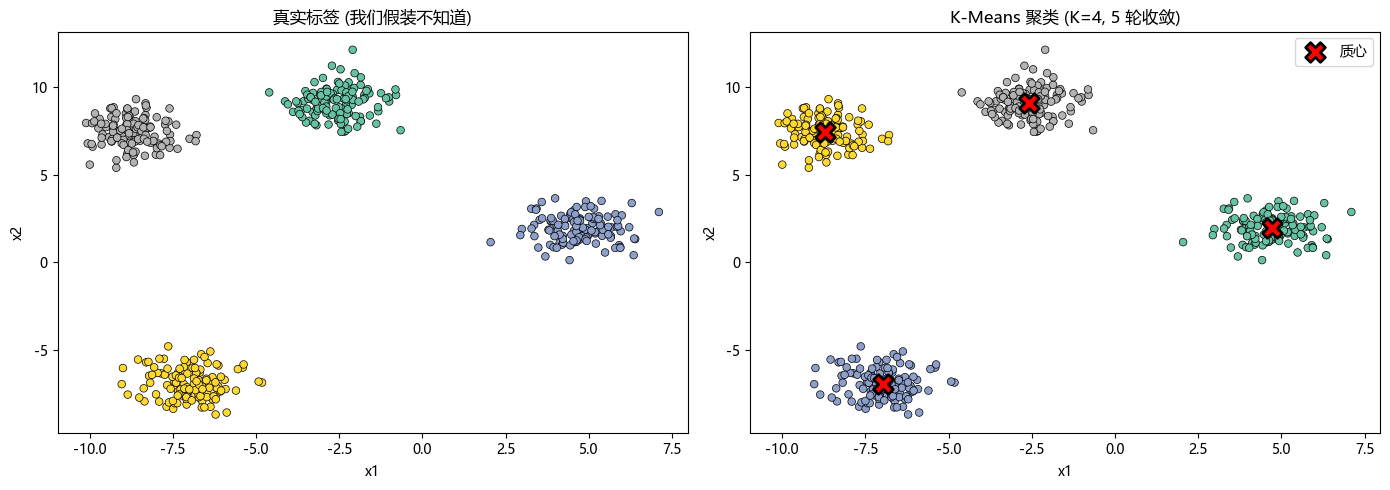

In [4]:
# 可视化聚类结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：真实标签
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='Set2', s=30, edgecolors='k', linewidth=0.5)
axes[0].set_title('真实标签 (我们假装不知道)')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

# 右：K-Means 聚类结果
axes[1].scatter(X[:, 0], X[:, 1], c=my_km.labels_, cmap='Set2', s=30, edgecolors='k', linewidth=0.5)
axes[1].scatter(my_km.centroids[:, 0], my_km.centroids[:, 1],
                c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='质心')
axes[1].set_title(f'K-Means 聚类 (K={my_km.K}, {my_km.n_iters_} 轮收敛)')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
axes[1].legend()

plt.tight_layout(); plt.show()

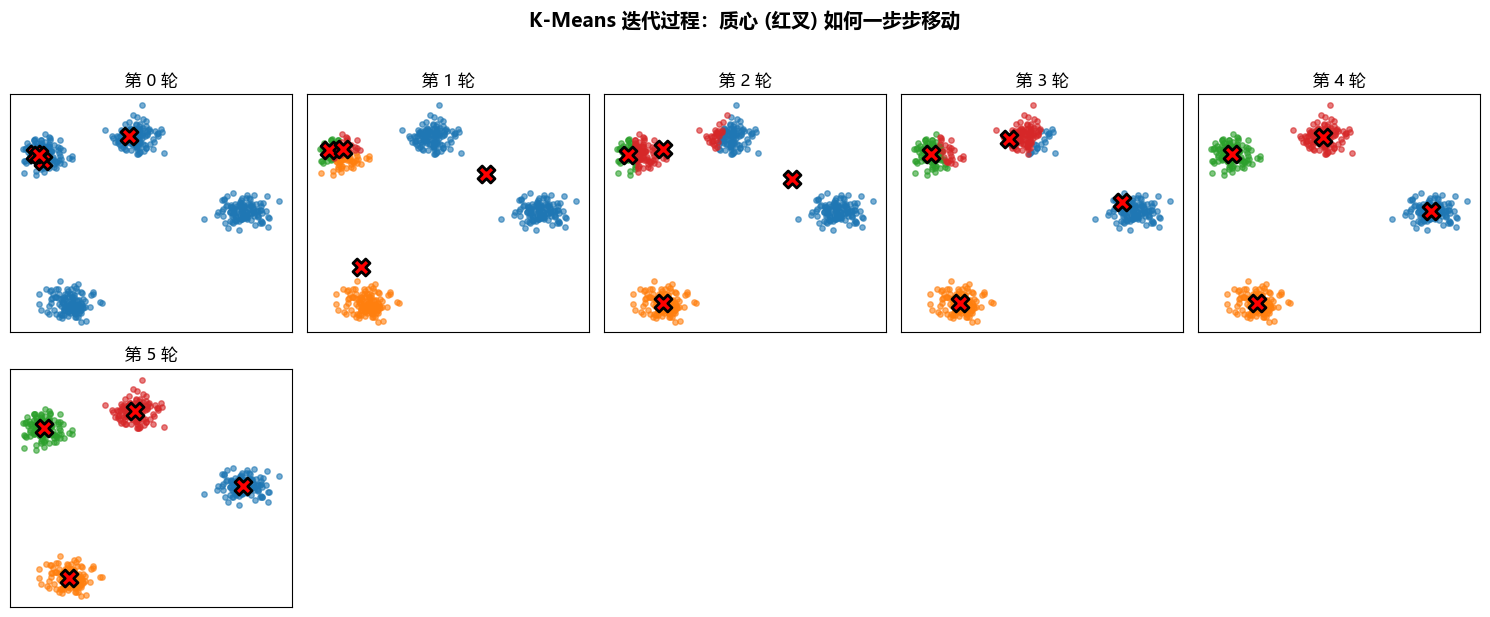

共 5 轮收敛，上图为每一轮的状态


In [5]:
# 可视化 K-Means 的迭代过程（看质心怎么一步一步移动的）
class MyKMeansTrace(MyKMeans):
    """记录每轮的质心和标签，用于可视化"""
    def fit(self, X):
        n, d = X.shape
        rng = np.random.RandomState(self.random_state)
        idx = rng.choice(n, self.K, replace=False)
        self.centroids = X[idx].copy().astype(float)

        self.history = []  # 记录每轮状态
        self.labels_ = np.zeros(n, dtype=int)
        self.history.append((self.centroids.copy(), self.labels_.copy()))

        for it in range(self.max_iters):
            distances = np.zeros((n, self.K))
            for k in range(self.K):
                distances[:, k] = np.sqrt(((X - self.centroids[k]) ** 2).sum(axis=1))
            self.labels_ = distances.argmin(axis=1)

            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.K):
                mask = self.labels_ == k
                if mask.sum() > 0:
                    new_centroids[k] = X[mask].mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]

            self.history.append((new_centroids.copy(), self.labels_.copy()))
            shift = np.sqrt(((new_centroids - self.centroids) ** 2).sum(axis=1)).max()
            self.centroids = new_centroids

            if shift < self.tol:
                break
        return self


km_trace = MyKMeansTrace(n_clusters=4, random_state=42)
km_trace.fit(X)

# 画迭代过程
n_steps = len(km_trace.history)
cols = min(5, n_steps)
rows = (n_steps + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = axes.ravel() if rows * cols > 1 else [axes]

for i, (centroids, labels) in enumerate(km_trace.history):
    ax = axes[i]
    for k in range(4):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.6)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='red', marker='X', s=150, edgecolors='black', linewidth=2)
    ax.set_title(f'第 {i} 轮')
    ax.set_xticks([]); ax.set_yticks([])

for i in range(n_steps, len(axes)):
    axes[i].axis('off')

plt.suptitle('K-Means 迭代过程：质心 (红叉) 如何一步步移动', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f'共 {n_steps - 1} 轮收敛，上图为每一轮的状态')

---

## 3. Elbow Method —— K 选几？

> 跑一遍 K=1,2,3,...,10，画 SSE 曲线，找拐点

SSE（簇内平方和）：
```
SSE = sum(每个点到它所属质心的距离的平方)
```
K 越大 → SSE 越小（极端：K=n 时 SSE=0）。但我们找的是**拐点**——过了这个点收益骤降。

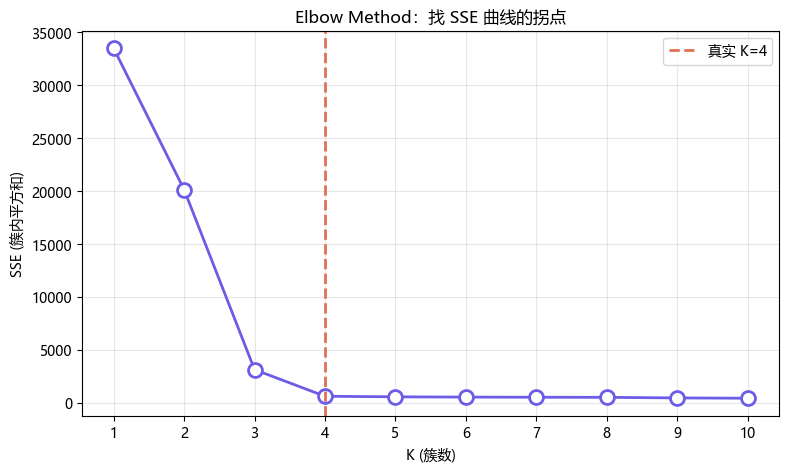

K  SSE      下降量
-------------------------
1   33484.0       0.0
2   20137.2   13346.8
3    3125.0   17012.2
4     607.3    2517.7 <- 拐点
5     551.7      55.6
6     528.2      23.5
7     513.0      15.3
8     504.6       8.3
9     448.2      56.4
10     420.9      27.3
观察: K=4 之后下降量骤减 → Elbow 指向 K=4


In [6]:
# Elbow method
K_range = range(1, 11)
sse_list = []

for k in K_range:
    km = MyKMeans(n_clusters=k, random_state=42)
    km.fit(X)
    sse_list.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, sse_list, 'o-', color='#6c5ce7', linewidth=2, markersize=10,
         markerfacecolor='white', markeredgewidth=2)
# 标出 K=4 的位置（真实值）
plt.axvline(x=4, color='#e17055', linestyle='--', linewidth=2, label='真实 K=4')
plt.xlabel('K (簇数)'); plt.ylabel('SSE (簇内平方和)')
plt.title('Elbow Method：找 SSE 曲线的拐点')
plt.legend(); plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

# 算相邻 K 的 SSE 下降量（delta）
deltas = [sse_list[i] - sse_list[i+1] for i in range(len(sse_list)-1)]
print('K  SSE      下降量')
print('-' * 25)
for k, sse, d in zip(K_range, sse_list, [0] + deltas):
    marker = ' <- 拐点' if k == 4 else ''
    print(f'{k}  {sse:8.1f}  {d:8.1f}{marker}')
print('观察: K=4 之后下降量骤减 → Elbow 指向 K=4')

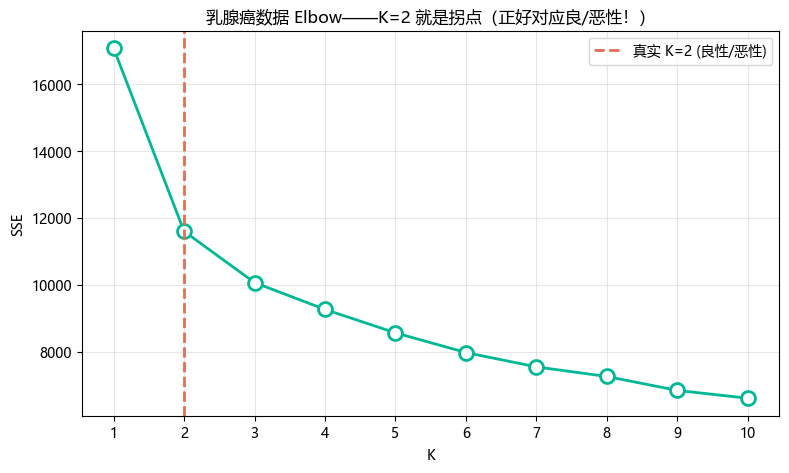

K-Means (K=2) vs 真实标签:
  直接匹配准确率: 0.0949
  翻转后准确率:   0.9051  <- 无监督也能逼近真实分类！


In [7]:
# 真实数据集上的 K-Means
data = load_breast_cancer()
X_cancer, y_cancer = data.data, data.target

# 标准化（K-Means 对尺度敏感！）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

# Elbow 找 K
sse_cancer = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse_cancer.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), sse_cancer, 'o-', color='#00b894', linewidth=2, markersize=10,
         markerfacecolor='white', markeredgewidth=2)
plt.axvline(x=2, color='#e17055', linestyle='--', linewidth=2, label='真实 K=2 (良性/恶性)')
plt.xlabel('K'); plt.ylabel('SSE')
plt.title('乳腺癌数据 Elbow——K=2 就是拐点（正好对应良/恶性！）')
plt.legend(); plt.xticks(range(1, 11)); plt.grid(True, alpha=0.3)
plt.show()

# K=2 聚类 vs 真实标签
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
km2.fit(X_scaled)
labels = km2.labels_

# 对齐标签（聚类标签 0/1 可能和真实标签相反）
acc1 = (labels == y_cancer).mean()
acc2 = (1 - labels == y_cancer).mean()
print(f'K-Means (K=2) vs 真实标签:')
print(f'  直接匹配准确率: {acc1:.4f}')
print(f'  翻转后准确率:   {max(acc1, acc2):.4f}  <- 无监督也能逼近真实分类！')

---

## 4. PCA —— 主成分分析，给数据降维

> 30 维特征画不出来 → 压到 2 维就能画了

**核心思想：** 找到数据方差最大的方向（主成分），把数据投影过去

**三步走：**
1. **中心化**：数据减去均值
2. **协方差矩阵**：找特征之间的关系
3. **特征值分解**：特征向量 = 主成分方向，特征值 = 该方向的方差

**C++ 角度类比：**
```
// PCA ≈ SVD（奇异值分解），本质是线性变换
// 把 n 维的点投影到 k 个最重要的方向上
// 就像从不同角度拍一个 3D 物体 → 选最能体现形状的那个 2D 投影
```

In [8]:
# === 手写 PCA ===
class MyPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None    # (n_components, d) 主成分方向
        self.mean_ = None          # (d,) 原始数据均值
        self.explained_variance_ = None        # 每个成分的方差
        self.explained_variance_ratio_ = None  # 方差占比

    def fit(self, X):
        # 1. 中心化
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        # 2. 协方差矩阵 C = (1/n) * X^T X
        n = X.shape[0]
        C = (X_centered.T @ X_centered) / n

        # 3. 特征值分解
        eigenvalues, eigenvectors = np.linalg.eigh(C)
        # eigh 返回升序 → 取最大的 n_components 个（倒序）
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # 4. 取前 n_components 个
        self.components_ = eigenvectors[:, :self.n_components].T  # (k, d)
        self.explained_variance_ = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()

        return self

    def transform(self, X):
        X_centered = X - self.mean_
        # 投影: Z = X_centered @ components^T
        return X_centered @ self.components_.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


# 用 digits 数据集验证（64维 → 2维）
digits = load_digits()
X_digits = digits.data  # (1797, 64)
y_digits = digits.target

my_pca = MyPCA(n_components=2)
X_pca = my_pca.fit_transform(X_digits)

print(f'原始维度: {X_digits.shape[1]}')
print(f'降维后:   {X_pca.shape[1]}')
print(f'前 2 个主成分方差占比: {my_pca.explained_variance_ratio_}')
print(f'累计方差占比: {my_pca.explained_variance_ratio_.sum():.3f}')
print(f'解释: 2维保留了 {my_pca.explained_variance_ratio_.sum()*100:.1f}% 的信息')

原始维度: 64
降维后:   2
前 2 个主成分方差占比: [0.14890594 0.13618771]
累计方差占比: 0.285
解释: 2维保留了 28.5% 的信息


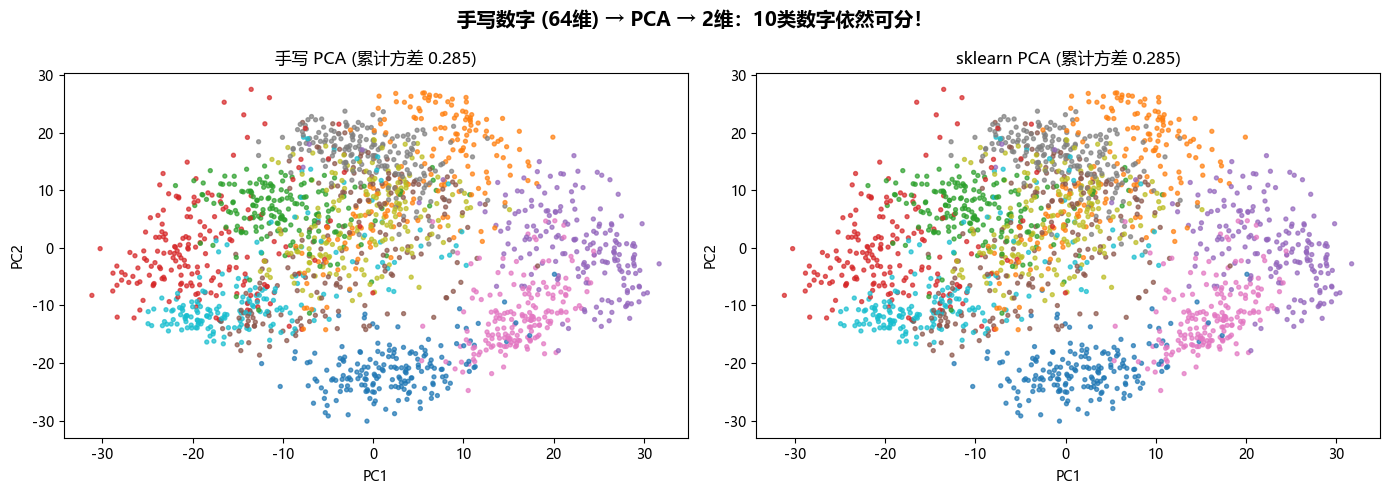

关键观察: 不用标签，PCA 自动找到了能分开数字的方向


In [9]:
# 降维后可视化——64维手写数字压到2维，还能分开！
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 用 sklearn PCA 验证
sk_pca = PCA(n_components=2)
X_skpca = sk_pca.fit_transform(X_digits)

# 左：手写 PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap='tab10', s=8, alpha=0.7)
axes[0].set_title(f'手写 PCA (累计方差 {my_pca.explained_variance_ratio_.sum():.3f})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# 右：sklearn PCA
axes[1].scatter(X_skpca[:, 0], X_skpca[:, 1], c=y_digits, cmap='tab10', s=8, alpha=0.7)
axes[1].set_title(f'sklearn PCA (累计方差 {sk_pca.explained_variance_ratio_.sum():.3f})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('手写数字 (64维) → PCA → 2维：10类数字依然可分！', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('关键观察: 不用标签，PCA 自动找到了能分开数字的方向')

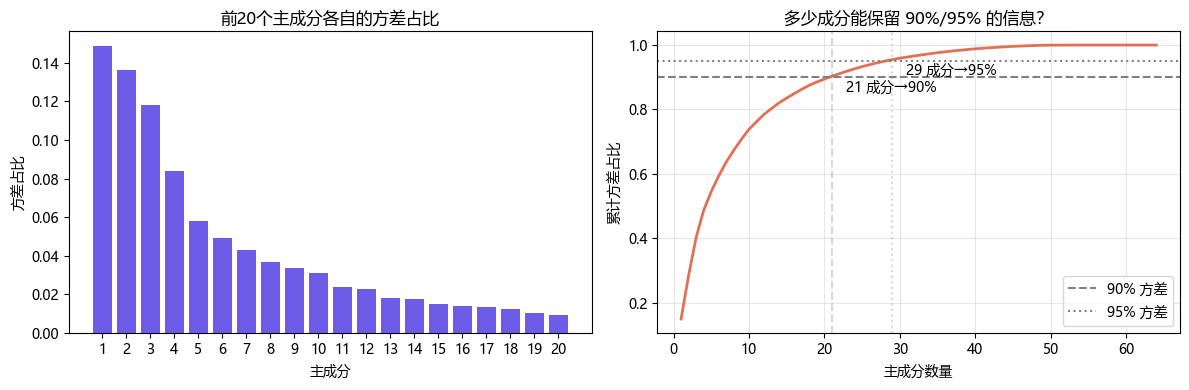

需要 21/64 个主成分保留 90% 方差
需要 29/64 个主成分保留 95% 方差
结论: 64维 → ~30维 几乎不失信息 → ~2维 还能看出结构


In [10]:
# PCA 完整流程：看每个主成分捕获了多少方差
pca_full = PCA().fit(X_digits)

plt.figure(figsize=(12, 4))

# 左：各成分方差占比
plt.subplot(1, 2, 1)
plt.bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color='#6c5ce7')
plt.xlabel('主成分'); plt.ylabel('方差占比')
plt.title('前20个主成分各自的方差占比')
plt.xticks(range(1, 21))

# 右：累计方差
plt.subplot(1, 2, 2)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, linewidth=2, color='#e17055')
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% 方差')
plt.axhline(y=0.95, color='gray', linestyle=':', label='95% 方差')
plt.xlabel('主成分数量'); plt.ylabel('累计方差占比')
plt.title('多少成分能保留 90%/95% 的信息？')
plt.legend(); plt.grid(True, alpha=0.3)

# 找 90% 和 95% 需要多少成分
n90 = (cumsum < 0.9).sum() + 1
n95 = (cumsum < 0.95).sum() + 1
plt.axvline(x=n90, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=n95, color='gray', linestyle=':', alpha=0.3)
plt.annotate(f'{n90} 成分→90%', (n90, 0.9), textcoords='offset points', xytext=(10,-10))
plt.annotate(f'{n95} 成分→95%', (n95, 0.95), textcoords='offset points', xytext=(10,-10))

plt.tight_layout(); plt.show()
print(f'需要 {n90}/{X_digits.shape[1]} 个主成分保留 90% 方差')
print(f'需要 {n95}/{X_digits.shape[1]} 个主成分保留 95% 方差')
print(f'结论: 64维 → ~30维 几乎不失信息 → ~2维 还能看出结构')

---

## 5. K-Means + PCA 组合拳

> 高维数据先 PCA 降维再聚类，既能可视化又能去噪

这是实际项目中最常见的 pipeline：
```
原始数据 → StandardScaler → PCA(降到2维) → KMeans(K=?)
```

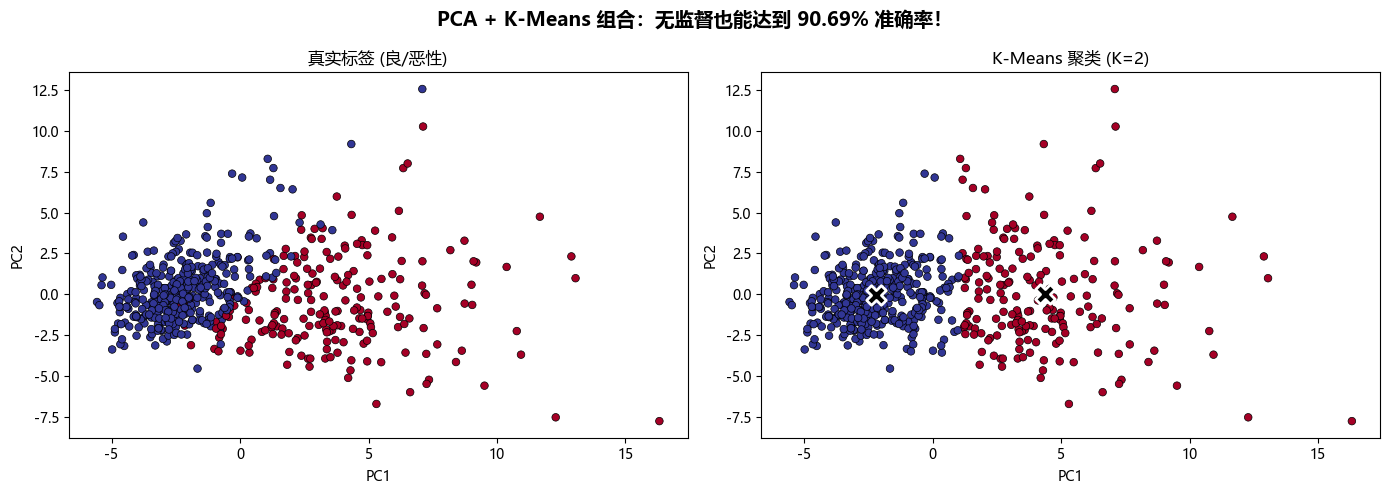

In [11]:
# 全流程：乳腺癌数据
# 1. 标准化
X_scaled = StandardScaler().fit_transform(X_cancer)

# 2. PCA 降维到 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# 3. K-Means 聚类
km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = km.fit_predict(X_2d)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_cancer, cmap='RdYlBu', s=30, edgecolors='k', linewidth=0.5)
axes[0].set_title('真实标签 (良/恶性)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='RdYlBu', s=30, edgecolors='k', linewidth=0.5)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='black', marker='X', s=200, edgecolors='white', linewidth=2)
axes[1].set_title(f'K-Means 聚类 (K=2)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

acc = max((labels == y_cancer).mean(), (1 - labels == y_cancer).mean())
plt.suptitle(f'PCA + K-Means 组合：无监督也能达到 {acc:.2%} 准确率！', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()



## 6. K-Means vs PCA —— 对比总结

| 维度 | K-Means | PCA |
|------|---------|-----|
| **类型** | 聚类（把样本分组） | 降维（压缩特征） |
| **输入** | 原始特征 | 原始特征 |
| **输出** | 每个点的簇标签 (n,) | 低维表示 (n, k) |
| **有监督？** | 无监督 | 无监督 |
| **核心数学** | 迭代优化 SSE | 特征值分解 |
| **调什么** | K（簇数） | n_components（保留维度） |
| **选参数方法** | Elbow method | 累计方差占比 |
| **能不能一起用？** | ✅ PCA → K-Means 是标配 pipeline |

---

# Day 6 完成！

## 今天手写了什么

| 手写类 | 核心 | 几行 |
|--------|------|------|
| **MyKMeans** | assign（分派） + update（更新）循环 | ~30 |
| **MyPCA** | 协方差矩阵 → 特征值分解 → 投影 | ~20 |

## 要刻进肌肉记忆的

```
K-Means:
  1. 随机选 K 个质心
  2. repeat:
       assign:  每点找最近质心
       update:  质心 = 簇内均值
     until 质心不动

PCA:
  1. 中心化: X - mean
  2. 协方差矩阵: C = X^T @ X / n
  3. 特征值分解 → 取最大 k 个特征向量
  4. 投影: Z = X @ components.T
```

## 晚上作业

1. 把 MyKMeans 的 K 从 2 试到 8，手动画 Elbow 图
2. 用 MyPCA 把乳腺癌数据（30维）降到 2 维，看良/恶性分开了吗
3. 思考题：K-Means 如果初始质心选的不好会怎样？（预习 KMeans++）
4. 预习 Day 7：周复习——六模型大乱斗，对比报告